**Cell 1 — Imports**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)

**Cell 2 — Load dataset**

In [18]:
DATA_PATH = "../data/raw/Telco_customer_churn.xlsx"

df = pd.read_excel(DATA_PATH)

df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


**Cell 4 — Column names**

In [19]:
df.columns.tolist()

['CustomerID',
 'Count',
 'Country',
 'State',
 'City',
 'Zip Code',
 'Lat Long',
 'Latitude',
 'Longitude',
 'Gender',
 'Senior Citizen',
 'Partner',
 'Dependents',
 'Tenure Months',
 'Phone Service',
 'Multiple Lines',
 'Internet Service',
 'Online Security',
 'Online Backup',
 'Device Protection',
 'Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Contract',
 'Paperless Billing',
 'Payment Method',
 'Monthly Charges',
 'Total Charges',
 'Churn Label',
 'Churn Value',
 'Churn Score',
 'CLTV',
 'Churn Reason']

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [21]:
df.sample(10, random_state=42)

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
185,2189-WWOEW,1,United States,California,Keene,93531,"35.214982, -118.59049",35.214982,-118.590490,Female,No,No,No,15,Yes,No,Fiber optic,No,Yes,No,No,No,Yes,Month-to-month,Yes,Bank transfer (automatic),85.90,1269.55,Yes,1,96,3579,Don't know
2715,2446-ZKVAF,1,United States,California,Stockton,95207,"38.002125, -121.324979",38.002125,-121.324979,Male,No,Yes,No,18,Yes,Yes,DSL,No,Yes,No,No,No,No,Month-to-month,No,Credit card (automatic),56.80,1074.65,No,0,59,5558,NaN
3825,4986-MXSFP,1,United States,California,San Leandro,94579,"37.687264, -122.15728",37.687264,-122.157280,Female,No,No,No,2,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,20.00,40.9,No,0,39,2237,NaN
1807,5868-YWPDW,1,United States,California,Sherman Oaks,91423,"34.146957, -118.432138",34.146957,-118.432138,Male,Yes,Yes,No,6,Yes,No,Fiber optic,No,Yes,No,No,No,Yes,Month-to-month,Yes,Electronic check,84.20,519.15,Yes,1,72,5834,Limited range of services
132,9412-GHEEC,1,United States,California,Murrieta,92563,"33.581045, -117.14719",33.581045,-117.147190,Male,No,No,No,40,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,No,Bank transfer (automatic),104.80,4131.95,Yes,1,88,3492,Service dissatisfaction
1263,3389-YGYAI,1,United States,California,Princeton,95970,"39.424957, -122.039307",39.424957,-122.039307,Female,Yes,No,No,8,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,105.50,829.55,Yes,1,72,5546,Price too high
3732,4927-WWOOZ,1,United States,California,Pacific Grove,93950,"36.618337, -121.926417",36.618337,-121.926417,Male,No,Yes,No,2,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,No,Month-to-month,Yes,Electronic check,91.45,171.45,No,0,32,4889,NaN
1672,4558-FANTW,1,United States,California,Fair Oaks,95628,"38.652065, -121.25441",38.652065,-121.254410,Female,No,Yes,No,17,Yes,No,Fiber optic,Yes,No,No,Yes,Yes,No,Month-to-month,No,Electronic check,91.85,1574.45,Yes,1,89,5643,Lack of affordable download/upload speed
811,6032-IGALN,1,United States,California,Granite Bay,95746,"38.749466, -121.184196",38.749466,-121.184196,Female,No,No,No,1,No,No phone service,DSL,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,25.10,25.1,Yes,1,79,4769,Service dissatisfaction
2526,3523-BRGUW,1,United States,California,Los Altos,94022,"37.349546, -122.134356",37.349546,-122.134356,Male,Yes,No,No,26,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Credit card (automatic),19.30,504.2,No,0,64,2269,NaN


In [22]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [23]:
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percentage": df.isna().mean() * 100
}).sort_values("missing_count", ascending=False)

missing

,missing_count,missing_percentage
Churn Reason,5174,73.463013
CustomerID,0,0.000000
Count,0,0.000000
State,0,0.000000
Country,0,0.000000
Zip Code,0,0.000000
Lat Long,0,0.000000
Latitude,0,0.000000
City,0,0.000000
Gender,0,0.000000


In [24]:
for col in df.select_dtypes(include="object").columns:
    blank_count = df[col].astype(str).str.strip().eq("").sum()

    if blank_count > 0:
        print(col, blank_count)

Total Charges 11


In [25]:
df["Total Charges"] = pd.to_numeric(
    df["Total Charges"],
    errors="coerce"
)

In [26]:
df[df["Total Charges"].isna()][
    ["CustomerID", "Tenure Months", "Monthly Charges", "Total Charges"]
]

,CustomerID,Tenure Months,Monthly Charges,Total Charges
2234,4472-LVYGI,0,52.55,NaN
2438,3115-CZMZD,0,20.25,NaN
2568,5709-LVOEQ,0,80.85,NaN
2667,4367-NUYAO,0,25.75,NaN
2856,1371-DWPAZ,0,56.05,NaN
4331,7644-OMVMY,0,19.85,NaN
4687,3213-VVOLG,0,25.35,NaN
5104,2520-SGTTA,0,20.00,NaN
5719,2923-ARZLG,0,19.70,NaN
6772,4075-WKNIU,0,73.35,NaN


In [27]:
unique_counts = df.nunique().sort_values()

unique_counts

Count                   1
Country                 1
State                   1
Phone Service           2
Dependents              2
Partner                 2
Senior Citizen          2
Gender                  2
Churn Value             2
Paperless Billing       2
Churn Label             2
Multiple Lines          3
Internet Service        3
Online Backup           3
Online Security         3
Tech Support            3
Contract                3
Streaming Movies        3
Streaming TV            3
Device Protection       3
Payment Method          4
Churn Reason           20
Tenure Months          73
Churn Score            85
City                 1129
Monthly Charges      1585
Longitude            1651
Latitude             1652
Lat Long             1652
Zip Code             1652
CLTV                 3438
Total Charges        6530
CustomerID           7043
dtype: int64

In [28]:
constant_cols = [
    col for col in df.columns
    if df[col].nunique(dropna=False) <= 1
]

constant_cols

['Count', 'Country', 'State']

In [29]:
df["Churn Label"].value_counts()

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

In [30]:
df["Churn Label"].value_counts(normalize=True) * 100

Churn Label
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

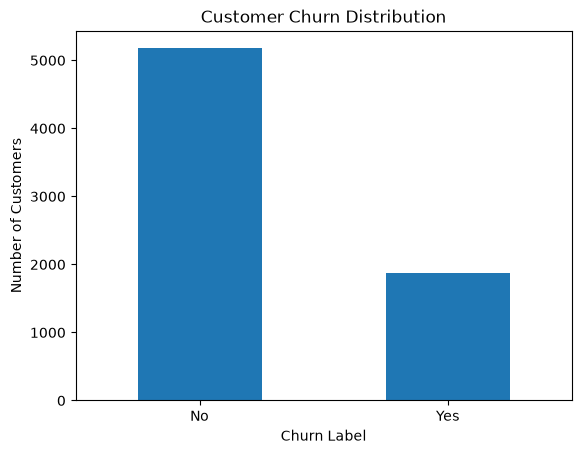

In [31]:
counts = df["Churn Label"].value_counts()

counts.plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Label")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

In [32]:
churn_rate = df["Churn Value"].mean() * 100

print(f"Overall churn rate: {churn_rate:.2f}%")

Overall churn rate: 26.54%


**Numerical EDA**

In [33]:
numeric_features = [
    "Tenure Months",
    "Monthly Charges",
    "Total Charges",
    "CLTV"
]

In [34]:
df[numeric_features].describe().T

,count,mean,std,min,25%,50%,75%,max
Tenure Months,7043.0,32.371149,24.559481,0.00,9.00,29.000,55.0000,72.00
Monthly Charges,7043.0,64.761692,30.090047,18.25,35.50,70.350,89.8500,118.75
Total Charges,7032.0,2283.300441,2266.771362,18.80,401.45,1397.475,3794.7375,8684.80
CLTV,7043.0,4400.295755,1183.057152,2003.00,3469.00,4527.000,5380.5000,6500.00


In [35]:
summary = pd.DataFrame({
    "mean": df[numeric_features].mean(),
    "median": df[numeric_features].median(),
    "std": df[numeric_features].std(),
    "skewness": df[numeric_features].skew()
})

summary

,mean,median,std,skewness
Tenure Months,32.371149,29.000,24.559481,0.239540
Monthly Charges,64.761692,70.350,30.090047,-0.220524
Total Charges,2283.300441,1397.475,2266.771362,0.961642
CLTV,4400.295755,4527.000,1183.057152,-0.311602


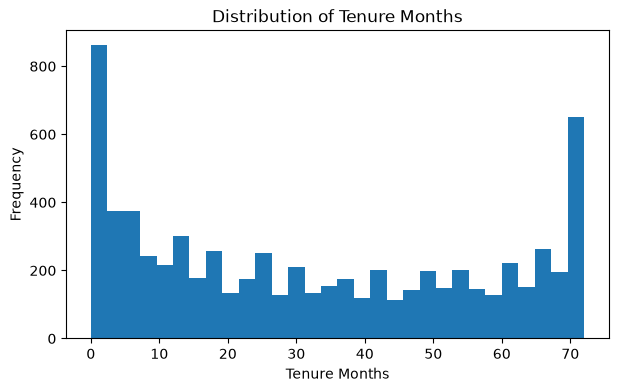

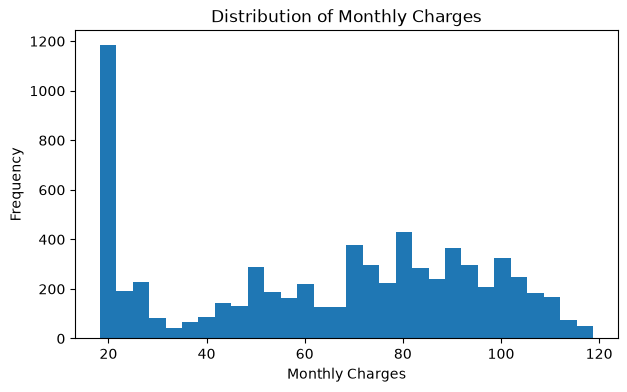

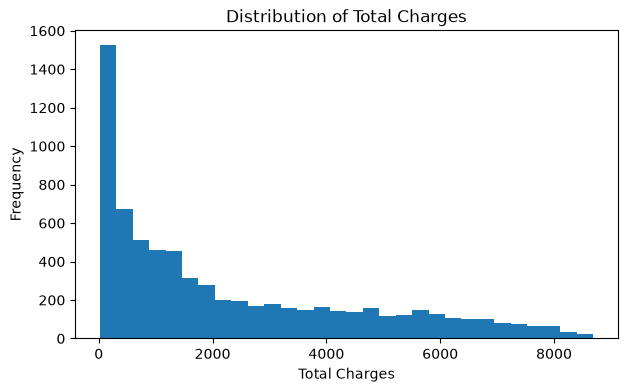

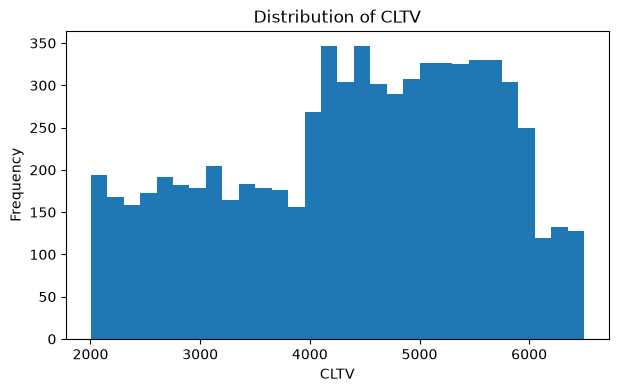

In [36]:
for col in numeric_features:
    plt.figure(figsize=(7, 4))

    plt.hist(
        df[col].dropna(),
        bins=30
    )

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_16540\3761780600.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


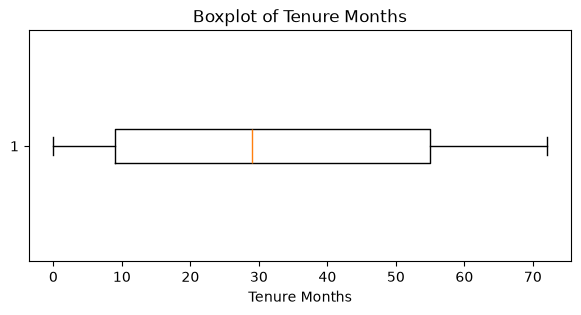

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_16540\3761780600.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


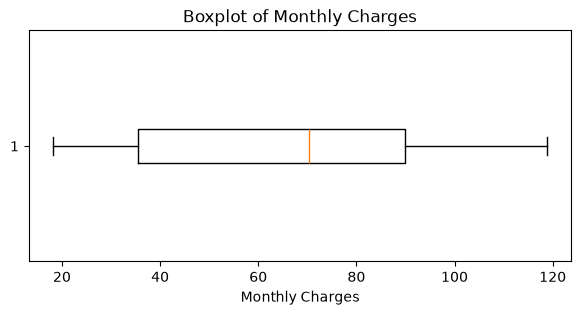

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_16540\3761780600.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


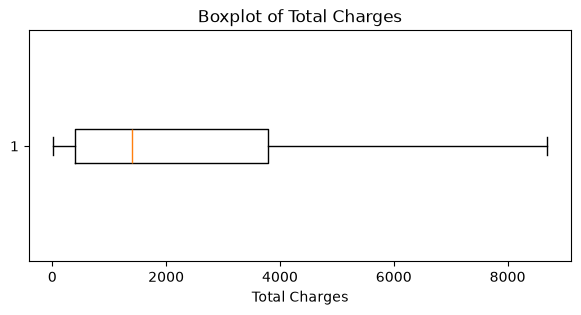

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_16540\3761780600.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


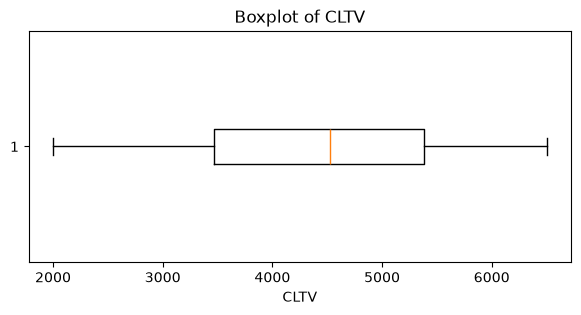

In [37]:
for col in numeric_features:
    plt.figure(figsize=(7, 3))

    plt.boxplot(
        df[col].dropna(),
        vert=False
    )

    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

In [38]:
df.groupby("Churn Label")[numeric_features].mean().T

Churn Label,No,Yes
Tenure Months,37.569965,17.979133
Monthly Charges,61.265124,74.441332
Total Charges,2555.344141,1531.796094
CLTV,4490.921337,4149.414660


In [39]:
df.groupby("Churn Label")[numeric_features].median().T

Churn Label,No,Yes
Tenure Months,38.000,10.00
Monthly Charges,64.425,79.65
Total Charges,1683.600,703.55
CLTV,4620.000,4238.00


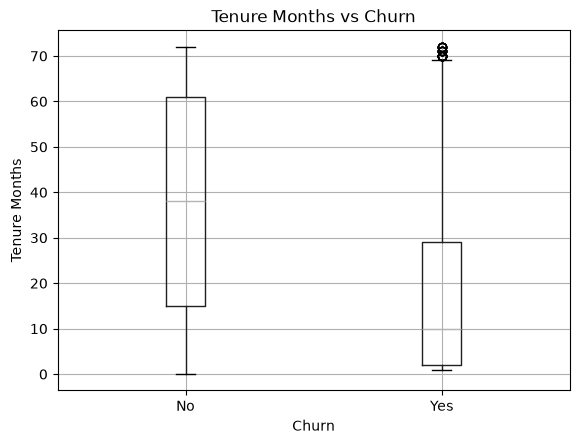

In [40]:
df.boxplot(
    column="Tenure Months",
    by="Churn Label"
)

plt.title("Tenure Months vs Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Tenure Months")
plt.show()

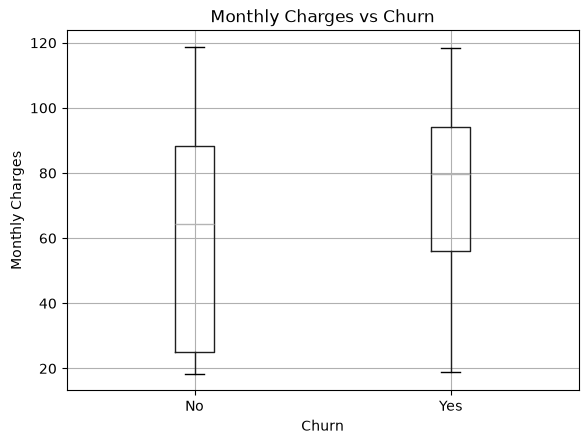

In [41]:
df.boxplot(
    column="Monthly Charges",
    by="Churn Label"
)

plt.title("Monthly Charges vs Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

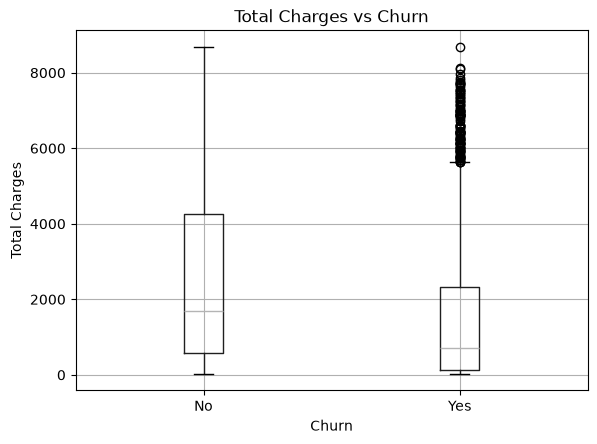

In [42]:
df.boxplot(
    column="Total Charges",
    by="Churn Label"
)

plt.title("Total Charges vs Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Total Charges")
plt.show()

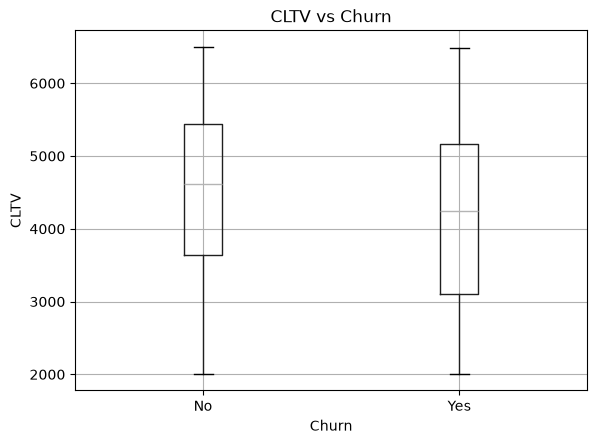

In [43]:
df.boxplot(
    column="CLTV",
    by="Churn Label"
)

plt.title("CLTV vs Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("CLTV")
plt.show()

**Categorical EDA**

In [44]:
categorical_features = [
    "Gender",
    "Senior Citizen",
    "Partner",
    "Dependents",
    "Phone Service",
    "Multiple Lines",
    "Internet Service",
    "Online Security",
    "Online Backup",
    "Device Protection",
    "Tech Support",
    "Streaming TV",
    "Streaming Movies",
    "Contract",
    "Paperless Billing",
    "Payment Method"
]

In [45]:
for col in categorical_features:
    print("\n", "=" * 50)
    print(col)
    print("=" * 50)

    print(df[col].value_counts())


Gender
Gender
Male      3555
Female    3488
Name: count, dtype: int64

Senior Citizen
Senior Citizen
No     5901
Yes    1142
Name: count, dtype: int64

Partner
Partner
No     3641
Yes    3402
Name: count, dtype: int64

Dependents
Dependents
No     5416
Yes    1627
Name: count, dtype: int64

Phone Service
Phone Service
Yes    6361
No      682
Name: count, dtype: int64

Multiple Lines
Multiple Lines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

Internet Service
Internet Service
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

Online Security
Online Security
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

Online Backup
Online Backup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64

Device Protection
Device Protection
No                     3095
Yes                    2422
N

In [46]:
for col in categorical_features:

    churn_rate = (
        df.groupby(col)["Churn Value"]
        .mean()
        .sort_values(ascending=False)
        * 100
    )

    print("\n", "=" * 50)
    print(f"Churn rate by {col}")
    print("=" * 50)

    print(churn_rate.round(2))


Churn rate by Gender
Gender
Female    26.92
Male      26.16
Name: Churn Value, dtype: float64

Churn rate by Senior Citizen
Senior Citizen
Yes    41.68
No     23.61
Name: Churn Value, dtype: float64

Churn rate by Partner
Partner
No     32.96
Yes    19.66
Name: Churn Value, dtype: float64

Churn rate by Dependents
Dependents
No     32.55
Yes     6.52
Name: Churn Value, dtype: float64

Churn rate by Phone Service
Phone Service
Yes    26.71
No     24.93
Name: Churn Value, dtype: float64

Churn rate by Multiple Lines
Multiple Lines
Yes                 28.61
No                  25.04
No phone service    24.93
Name: Churn Value, dtype: float64

Churn rate by Internet Service
Internet Service
Fiber optic    41.89
DSL            18.96
No              7.40
Name: Churn Value, dtype: float64

Churn rate by Online Security
Online Security
No                     41.77
Yes                    14.61
No internet service     7.40
Name: Churn Value, dtype: float64

Churn rate by Online Backup
Online Ba

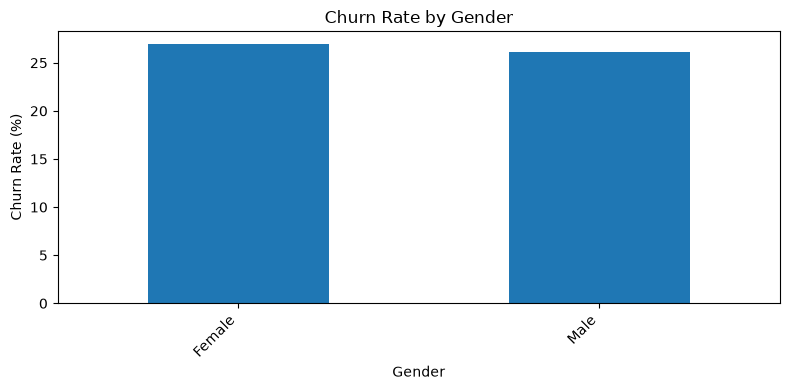

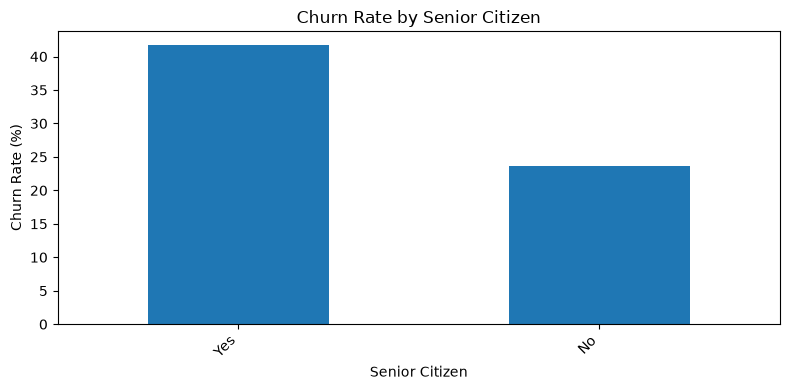

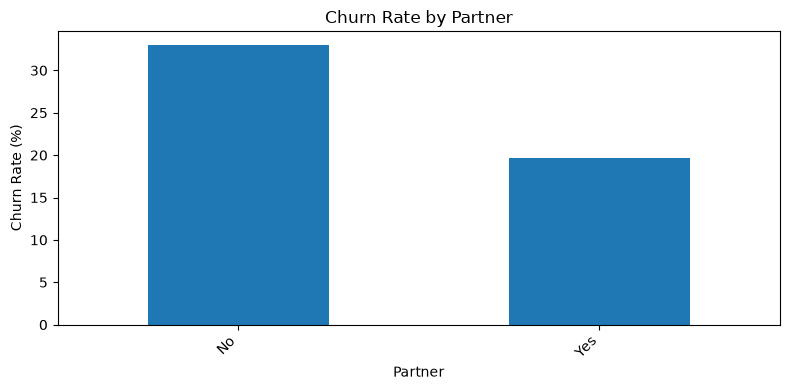

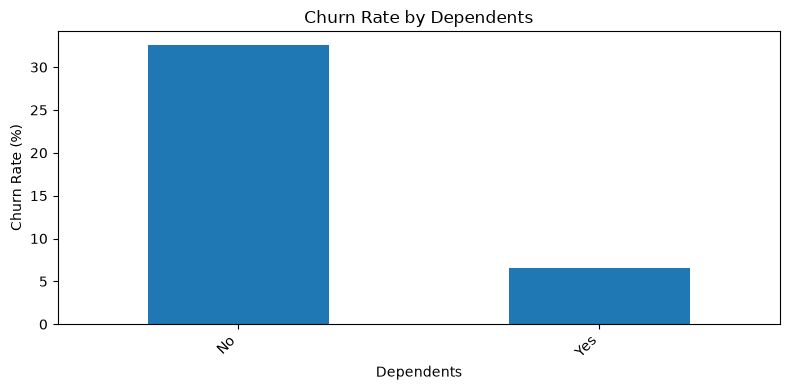

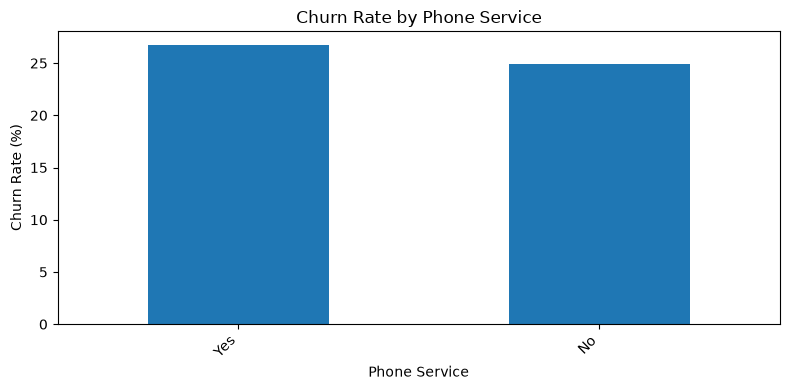

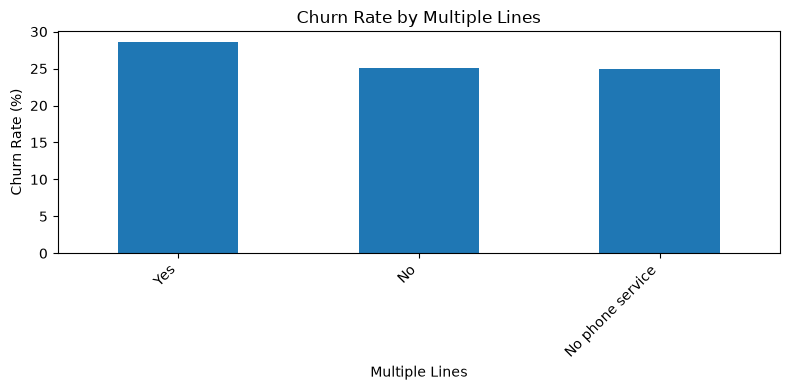

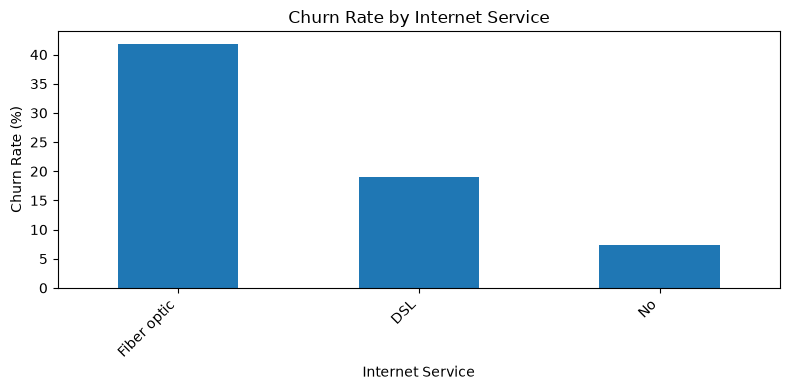

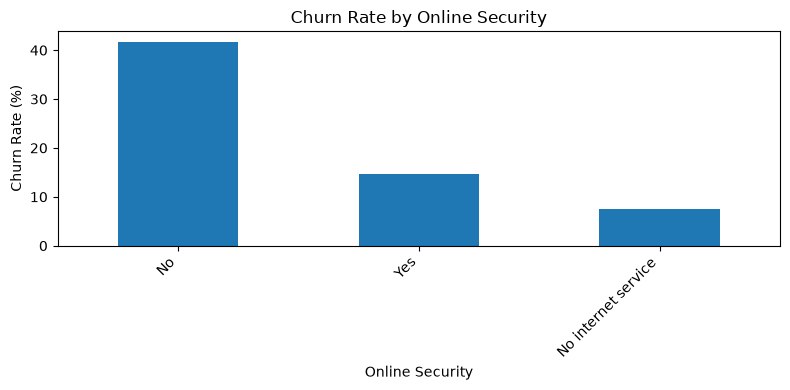

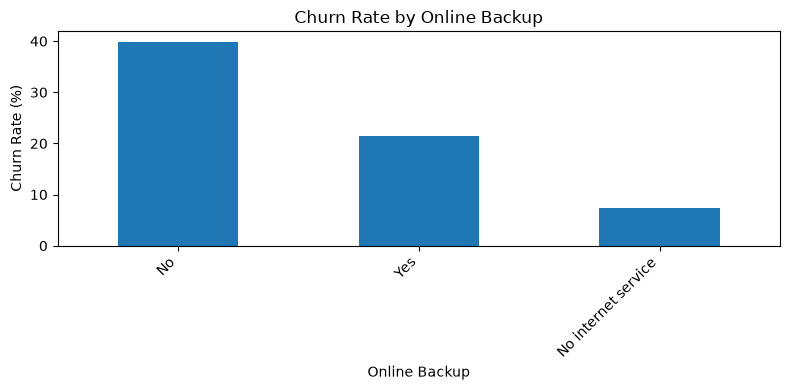

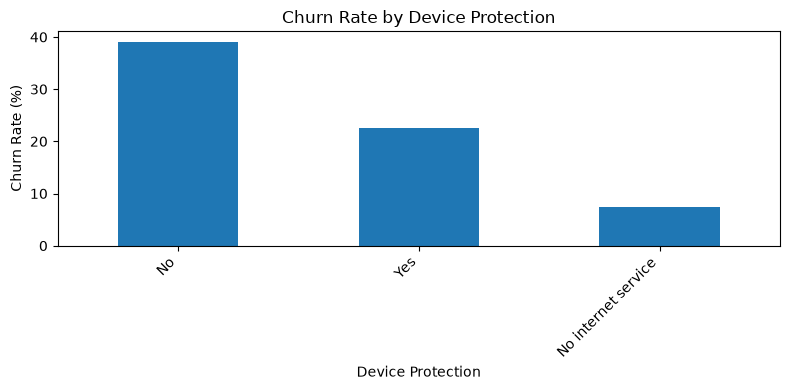

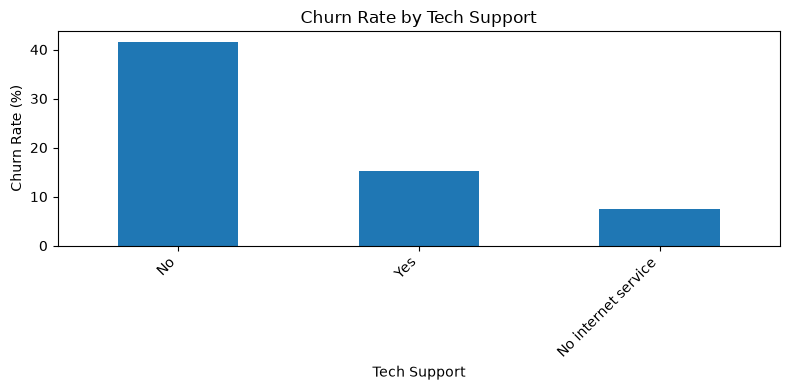

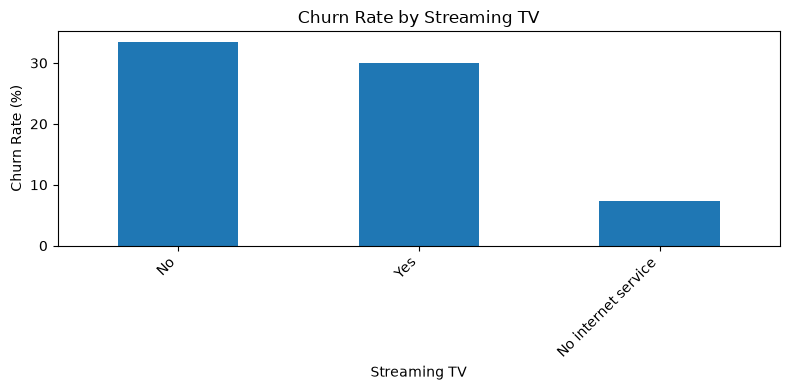

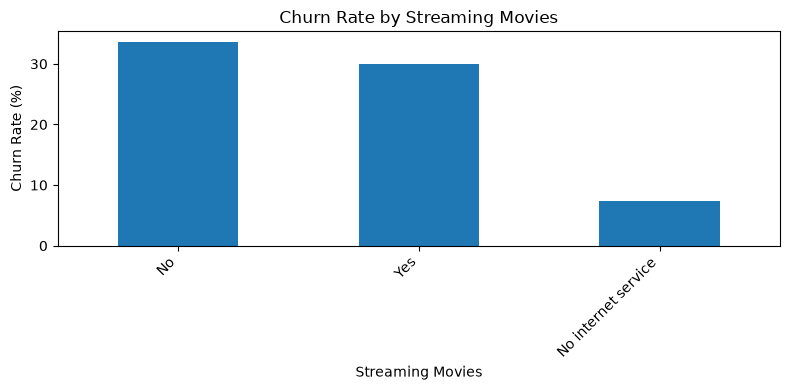

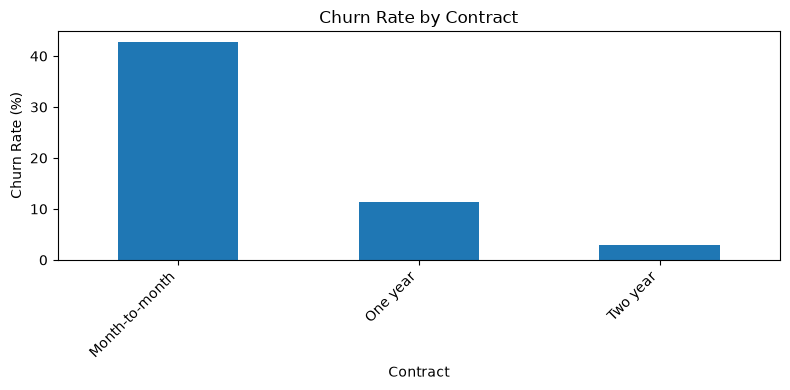

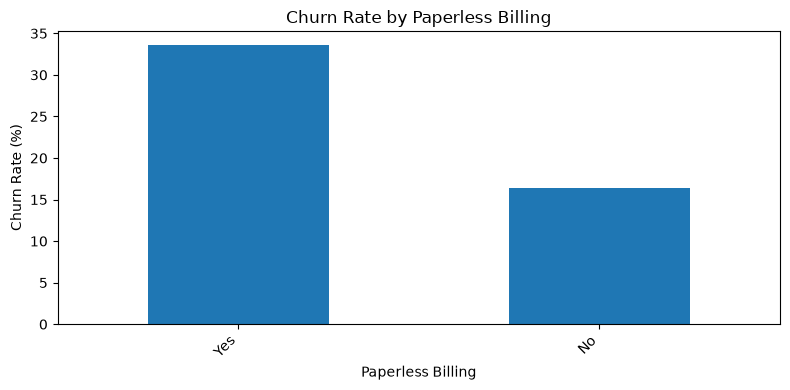

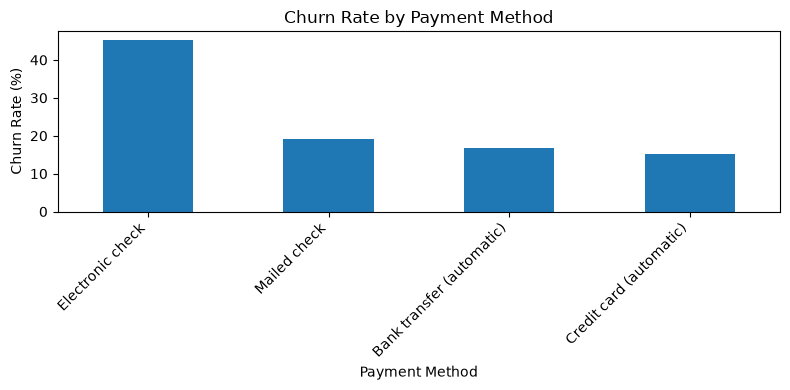

In [47]:
for col in categorical_features:

    churn_rate = (
        df.groupby(col)["Churn Value"]
        .mean()
        .sort_values(ascending=False)
        * 100
    )

    plt.figure(figsize=(8, 4))

    churn_rate.plot(kind="bar")

    plt.title(f"Churn Rate by {col}")
    plt.xlabel(col)
    plt.ylabel("Churn Rate (%)")
    plt.xticks(rotation=45, ha="right")

    plt.tight_layout()
    plt.show()

In [48]:
pd.crosstab(
    df["Contract"],
    df["Churn Label"],
    normalize="index"
) * 100

Churn Label,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


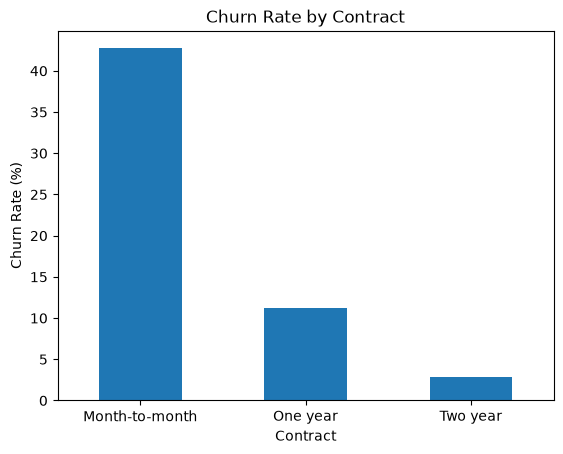

In [49]:
contract_churn = (
    df.groupby("Contract")["Churn Value"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

contract_churn.plot(kind="bar")

plt.title("Churn Rate by Contract")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [50]:
payment_churn = (
    df.groupby("Payment Method")["Churn Value"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

payment_churn

Payment Method
Electronic check             45.285412
Mailed check                 19.106700
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Name: Churn Value, dtype: float64

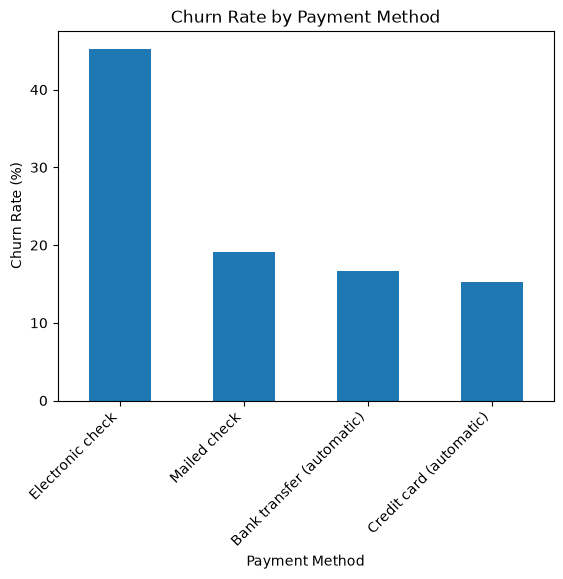

In [51]:
payment_churn.plot(kind="bar")

plt.title("Churn Rate by Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.show()

In [52]:
internet_churn = (
    df.groupby("Internet Service")["Churn Value"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

internet_churn

Internet Service
Fiber optic    41.892765
DSL            18.959108
No              7.404980
Name: Churn Value, dtype: float64

In [53]:
tech_support_churn = (
    df.groupby("Tech Support")["Churn Value"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

tech_support_churn

Tech Support
No                     41.635474
Yes                    15.166341
No internet service     7.404980
Name: Churn Value, dtype: float64

In [54]:
online_security_churn = (
    df.groupby("Online Security")["Churn Value"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

online_security_churn

Online Security
No                     41.766724
Yes                    14.611194
No internet service     7.404980
Name: Churn Value, dtype: float64

**Feature engineering for EDA**

In [55]:
df["Tenure Group"] = pd.cut(
    df["Tenure Months"],
    bins=[-1, 12, 24, 36, 48, 60, 72],
    labels=[
        "0-12 months",
        "13-24 months",
        "25-36 months",
        "37-48 months",
        "49-60 months",
        "61-72 months"
    ]
)

In [56]:
tenure_churn = (
    df.groupby("Tenure Group", observed=False)["Churn Value"]
    .mean()
    * 100
)

tenure_churn

Tenure Group
0-12 months     47.438243
13-24 months    28.710938
25-36 months    21.634615
37-48 months    19.028871
49-60 months    14.423077
61-72 months     6.609808
Name: Churn Value, dtype: float64

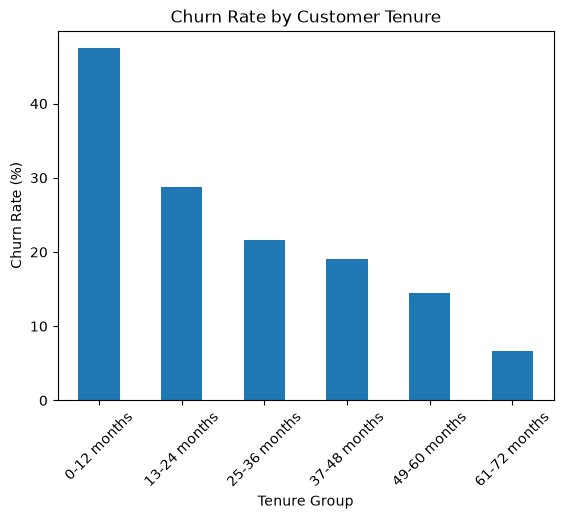

In [57]:
tenure_churn.plot(kind="bar")

plt.title("Churn Rate by Customer Tenure")
plt.ylabel("Churn Rate (%)")
plt.xlabel("Tenure Group")
plt.xticks(rotation=45)
plt.show()

In [58]:
df["Monthly Charge Group"] = pd.qcut(
    df["Monthly Charges"],
    q=4,
    labels=[
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

In [59]:
monthly_charge_churn = (
    df.groupby(
        "Monthly Charge Group",
        observed=False
    )["Churn Value"]
    .mean()
    * 100
)

monthly_charge_churn

Monthly Charge Group
Low          11.237230
Medium       24.575311
High         37.507114
Very High    32.878271
Name: Churn Value, dtype: float64

In [60]:
correlation_cols = [
    "Tenure Months",
    "Monthly Charges",
    "Total Charges",
    "CLTV",
    "Churn Value"
]

corr = df[correlation_cols].corr()

corr

,Tenure Months,Monthly Charges,Total Charges,CLTV,Churn Value
Tenure Months,1.000000,0.247900,0.825880,0.396406,-0.352229
Monthly Charges,0.247900,1.000000,0.651065,0.098693,0.193356
Total Charges,0.825880,0.651065,1.000000,0.341837,-0.199484
CLTV,0.396406,0.098693,0.341837,1.000000,-0.127463
Churn Value,-0.352229,0.193356,-0.199484,-0.127463,1.000000


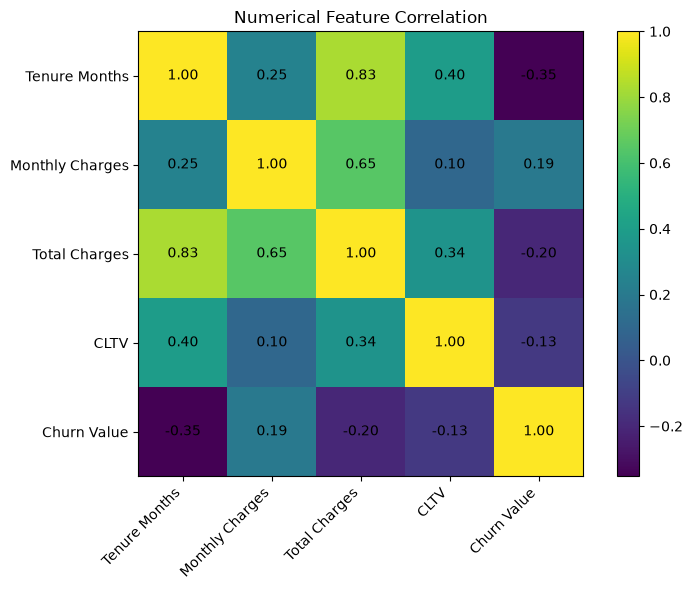

In [61]:
fig, ax = plt.subplots(figsize=(8, 6))

image = ax.imshow(corr)

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))

ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(
            j,
            i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Numerical Feature Correlation")
plt.colorbar(image)
plt.tight_layout()
plt.show()

In [62]:
for col in ["Country", "State", "City", "Zip Code"]:
    print(
        col,
        "->",
        df[col].nunique()
    )

Country -> 1
State -> 1
City -> 1129
Zip Code -> 1652


In [63]:
city_stats = (
    df.groupby("City")
    .agg(
        customers=("CustomerID", "count"),
        churn_rate=("Churn Value", "mean")
    )
)

city_stats["churn_rate"] *= 100

city_stats = city_stats[
    city_stats["customers"] >= 20
]

city_stats.sort_values(
    "churn_rate",
    ascending=False
).head(20)

,customers,churn_rate
City,,
Santa Rosa,24,45.833333
North Hollywood,20,45.000000
Modesto,28,42.857143
Santa Barbara,28,35.714286
San Diego,150,33.333333
Glendale,40,32.500000
Torrance,25,32.000000
Pasadena,30,30.000000
San Francisco,104,29.807692


In [64]:
churned_df = df[df["Churn Value"] == 1]

churned_df["Churn Reason"].value_counts()

Churn Reason
Attitude of support person                   192
Competitor offered higher download speeds    189
Competitor offered more data                 162
Don't know                                   154
Competitor made better offer                 140
Attitude of service provider                 135
Competitor had better devices                130
Network reliability                          103
Product dissatisfaction                      102
Price too high                                98
Service dissatisfaction                       89
Lack of self-service on Website               88
Extra data charges                            57
Moved                                         53
Lack of affordable download/upload speed      44
Limited range of services                     44
Long distance charges                         44
Poor expertise of phone support               20
Poor expertise of online support              19
Deceased                                       6
Name: c

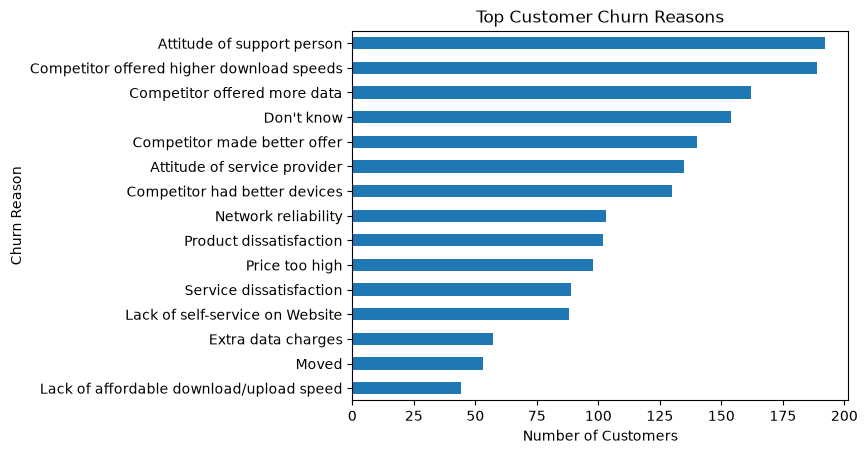

In [65]:
reason_counts = (
    churned_df["Churn Reason"]
    .value_counts()
    .head(15)
)

reason_counts.plot(kind="barh")

plt.title("Top Customer Churn Reasons")
plt.xlabel("Number of Customers")
plt.ylabel("Churn Reason")
plt.gca().invert_yaxis()
plt.show()

In [66]:
df["CLTV"].describe()

count    7043.000000
mean     4400.295755
std      1183.057152
min      2003.000000
25%      3469.000000
50%      4527.000000
75%      5380.500000
max      6500.000000
Name: CLTV, dtype: float64

In [67]:
df.groupby("Churn Label")["CLTV"].agg(
    ["mean", "median", "min", "max"]
)

,mean,median,min,max
Churn Label,,,,
No,4490.921337,4620.0,2003,6500
Yes,4149.414660,4238.0,2003,6484


In [68]:
churned_cltv = df.loc[
    df["Churn Value"] == 1,
    "CLTV"
].sum()

print(
    f"Total CLTV associated with churned customers: {churned_cltv:,.0f}"
)

Total CLTV associated with churned customers: 7,755,256


In [69]:
pd.pivot_table(
    df,
    values="Churn Value",
    index="Contract",
    columns="Tenure Group",
    aggfunc="mean"
) * 100

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_16540\2993760312.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pd.pivot_table(


Tenure Group,0-12 months,13-24 months,25-36 months,37-48 months,49-60 months,61-72 months
Contract,,,,,,
Month-to-month,51.354062,37.720488,32.510288,33.544304,27.777778,22.222222
One year,10.483871,8.121827,8.000000,13.059701,13.707165,12.140575
Two year,0.000000,0.000000,2.083333,2.247191,3.971119,3.144016


In [70]:
pd.pivot_table(
    df,
    values="Churn Value",
    index="Contract",
    columns="Internet Service",
    aggfunc="mean"
) * 100

Internet Service,DSL,Fiber optic,No
Contract,,,
Month-to-month,32.215863,54.605263,18.893130
One year,9.298246,19.294991,2.472527
Two year,1.910828,7.226107,0.783699


In [71]:
pd.pivot_table(
    df,
    values="Churn Value",
    index="Tech Support",
    columns="Contract",
    aggfunc="mean"
) * 100

Contract,Month-to-month,One year,Two year
Tech Support,,,
No,50.373134,14.721724,5.932203
No internet service,18.893130,2.472527,0.783699
Yes,30.700447,13.586957,3.532278


In [72]:
leakage_columns = [
    "Churn Label",
    "Churn Score",
    "Churn Reason"
]

identifier_columns = [
    "CustomerID"
]

possible_redundant_columns = [
    "Count",
    "Lat Long"
]

In [73]:
drop_for_model = [
    "CustomerID",
    "Count",
    "Country",
    "State",
    "Lat Long",
    "Churn Label",
    "Churn Score",
    "Churn Reason"
]

model_df = df.drop(
    columns=drop_for_model,
    errors="ignore"
)

model_df.head()

,City,Zip Code,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value,CLTV,Tenure Group,Monthly Charge Group
0,Los Angeles,90003,33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,3239,0-12 months,Medium
1,Los Angeles,90005,34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,2701,0-12 months,High
2,Los Angeles,90006,34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1,5372,0-12 months,Very High
3,Los Angeles,90010,34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1,5003,25-36 months,Very High
4,Los Angeles,90015,34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,1,5340,49-60 months,Very High


In [ ]:
drop_for_baseline = [
    "CustomerID",
    "Count",
    "Country",
    "State",
    "City",
    "Zip Code",
    "Lat Long",
    "Latitude",
    "Longitude",
    "Churn Label",
    "Churn Score",
    "Churn Reason"
]

baseline_df = df.drop(
    columns=drop_for_baseline,
    errors="ignore"
)

In [75]:
baseline_df.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value,CLTV,Tenure Group,Monthly Charge Group
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,3239,0-12 months,Medium
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,2701,0-12 months,High
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1,5372,0-12 months,Very High
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1,5003,25-36 months,Very High
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,1,5340,49-60 months,Very High


In [76]:
def categorical_churn_summary(
    dataframe,
    feature,
    target="Churn Value"
):
    summary = (
        dataframe
        .groupby(feature)
        .agg(
            customer_count=(target, "size"),
            churn_count=(target, "sum"),
            churn_rate=(target, "mean")
        )
        .reset_index()
    )

    summary["churn_rate"] *= 100

    return summary.sort_values(
        "churn_rate",
        ascending=False
    )

In [77]:
categorical_churn_summary(
    df,
    "Contract"
)

,Contract,customer_count,churn_count,churn_rate
0,Month-to-month,3875,1655,42.709677
1,One year,1473,166,11.269518
2,Two year,1695,48,2.831858


In [78]:
print("Dataset Shape:", df.shape)

print(
    "Duplicate Rows:",
    df.duplicated().sum()
)

print(
    "Customer ID Duplicates:",
    df["CustomerID"].duplicated().sum()
)

print(
    "Overall Churn Rate:",
    round(df["Churn Value"].mean() * 100, 2),
    "%"
)

print(
    "Total Missing Values:",
    df.isna().sum().sum()
)

print(
    "Number of Numerical Columns:",
    len(df.select_dtypes(include=np.number).columns)
)

print(
    "Number of Categorical Columns:",
    len(df.select_dtypes(include="object").columns)
)

Dataset Shape: (7043, 35)
Duplicate Rows: 0
Customer ID Duplicates: 0
Overall Churn Rate: 26.54 %
Total Missing Values: 5185
Number of Numerical Columns: 10
Number of Categorical Columns: 23
